In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [98]:
factories_df = pd.read_csv("./data/US Candy Distributors/Candy_Factories.csv")
products_df = pd.read_csv("./data/US Candy Distributors/Candy_Products.csv")
sales_df = pd.read_csv("./data/US Candy Distributors/Candy_Sales.csv", parse_dates=["Ship Date", "Order Date"])
targets_df = pd.read_csv("./data/US Candy Distributors/Candy_Targets.csv")
uszips_df = pd.read_csv("./data/US Candy Distributors/uszips.csv", dtype={"zip": str})

In [99]:
candy_sales_dfs = {
    "Candy Factories": factories_df,
    "Candy Products": products_df,
    "Candy Sales": sales_df,
    "Candy Tragets": targets_df,
    "US zips": uszips_df
}

for name, df in candy_sales_dfs.items():
    print("=" * 20)
    print(name)
    print("=" * 20)

    print(df.dtypes)
    print("No. of rows:", df.shape[0])
    print("")
    print(df.head(2))
    print("")
    print("*" * 100)
    print("")


Candy Factories
Factory          str
Latitude     float64
Longitude    float64
dtype: object
No. of rows: 5

           Factory   Latitude   Longitude
0    Lot's O' Nuts  32.881893 -111.768036
1  Wicked Choccy's  32.076176  -81.088371

****************************************************************************************************

Candy Products
Division            str
Product Name        str
Factory             str
Product ID          str
Unit Price      float64
Unit Cost       float64
dtype: object
No. of rows: 15

    Division                       Product Name        Factory     Product ID  \
0  Chocolate  Wonka Bar - Nutty Crunch Surprise  Lot's O' Nuts  CHO-NUT-13000   
1  Chocolate          Wonka Bar - Fudge Mallows  Lot's O' Nuts  CHO-FUD-51000   

   Unit Price  Unit Cost  
0        3.49        1.0  
1        3.60        1.2  

****************************************************************************************************

Candy Sales
Row ID                     int64

## Columns rename

In [100]:
def rename_columns(df):
    return [col.lower().replace(" ", "_").replace("/", "_") for col in df.columns]

for df in candy_sales_dfs.values():
    df.columns = rename_columns(df)

## apply()

In [101]:
sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28


### Calculate the Gross Profit %

```
Gross Profit % = (Sales - Cost) / Cost
```

In [102]:
round((sales_df["sales"] - sales_df["cost"]) / sales_df["cost"] * 100, 2)

0        188.46
1        227.27
2        200.00
3        185.09
4        185.09
          ...  
10189    227.27
10190    249.00
10191    188.46
10192    188.46
10193    200.00
Length: 10194, dtype: float64

In [103]:
sales_df.apply(lambda row: (row["sales"] - row["cost"]) / row["cost"] * 100, axis=1)

0        188.461538
1        227.272727
2        200.000000
3        185.087719
4        185.087719
            ...    
10189    227.272727
10190    249.000000
10191    188.461538
10192    188.461538
10193    200.000000
Length: 10194, dtype: float64

In [104]:
def calc_gross_profit(row):
    sales = row["sales"]
    cost = row["cost"]

    gross_profit = (sales - cost) / cost * 100
    return round(gross_profit, 2)

sales_df.apply(calc_gross_profit, axis=1)

0        188.46
1        227.27
2        200.00
3        185.09
4        185.09
          ...  
10189    227.27
10190    249.00
10191    188.46
10192    188.46
10193    200.00
Length: 10194, dtype: float64

In [105]:
sales_df["gross_profit_percent"] = sales_df.apply(calc_gross_profit, axis=1)

In [106]:
sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,region,product_id,product_name,sales,units,gross_profit,cost,gross_profit_percent
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,188.46
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,227.27
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,200.00
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,185.09
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,185.09


In [107]:
df_1 = sales_df[["sales", "units", "cost", "gross_profit"]]

df_1.apply(sum, axis=0)

sales           141783.63
units            38654.00
cost             48340.83
gross_profit     93442.80
dtype: float64

In [108]:
df_1.head()

,sales,units,cost,gross_profit
0,7.50,2,2.60,4.90
1,7.20,2,2.20,5.00
2,7.20,2,2.40,4.80
3,9.75,3,3.42,6.33
4,6.50,2,2.28,4.22


In [109]:
df_1["sales"] + df_1["units"] + df_1["cost"] + df_1["gross_profit"]

0        17.0
1        16.4
2        16.4
3        22.5
4        15.0
         ... 
10189    32.8
10190    39.9
10191    17.0
10192    42.5
10193    24.6
Length: 10194, dtype: float64

### Question: Find the month over month growth %

In [110]:
sales_df["order_year"] = sales_df["order_date"].dt.year
sales_df["order_month"] = sales_df["order_date"].dt.month

sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,region,product_id,product_name,sales,units,gross_profit,cost,gross_profit_percent,order_year,order_month
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,188.46,2021,3
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20,227.27,2021,3
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,200.00,2021,9
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,185.09,2021,9
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,185.09,2022,10


In [111]:
monthly_sales_df = sales_df.groupby(["order_year", "order_month"]).agg(total_sales=("sales", "sum"))
monthly_sales_df.head(15)

total_sales
order_year order_month             
2021       1                1065.24
           2                 547.09
           3                2245.63
           4                2058.97
           5                1855.21
           6                1838.43
           7                1908.23
           8                2258.46
           9                3927.08
           10               2544.88
           11               4357.18
           12               4347.15
2022       1                1028.66
           2                 832.78
           3                1893.27

In [112]:
prev_month_sales_df = monthly_sales_df.groupby(["order_year"]).shift(1).rename(columns={"total_sales": "prev_month_sales"})
prev_month_sales_df.head()

prev_month_sales
order_year order_month                  
2021       1                         NaN
           2                     1065.24
           3                      547.09
           4                     2245.63
           5                     2058.97

In [113]:
monthly_sales_joined_df = monthly_sales_df.join(prev_month_sales_df)
monthly_sales_joined_df.head()

total_sales  prev_month_sales
order_year order_month                               
2021       1                1065.24               NaN
           2                 547.09           1065.24
           3                2245.63            547.09
           4                2058.97           2245.63
           5                1855.21           2058.97

In [114]:
def mom_growth(row):
    current_month_sales = row["total_sales"]
    previous_month_sales = row["prev_month_sales"]

    growth = (current_month_sales - previous_month_sales) / previous_month_sales * 100

    return round(growth, 2)

monthly_sales_joined_df["MoM_growth"] = monthly_sales_joined_df.apply(mom_growth, axis=1)
monthly_sales_joined_df.head()

total_sales  prev_month_sales  MoM_growth
order_year order_month                                           
2021       1                1065.24               NaN         NaN
           2                 547.09           1065.24      -48.64
           3                2245.63            547.09      310.47
           4                2058.97           2245.63       -8.31
           5                1855.21           2058.97       -9.90

<Axes: xlabel='order_year,order_month'>

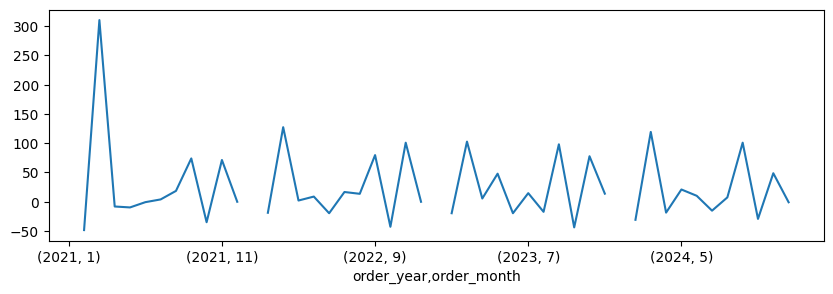

In [115]:
monthly_sales_joined_df["MoM_growth"].plot(figsize=(10, 3))

## transform()

In [116]:
df_1.head()

,sales,units,cost,gross_profit
0,7.50,2,2.60,4.90
1,7.20,2,2.20,5.00
2,7.20,2,2.40,4.80
3,9.75,3,3.42,6.33
4,6.50,2,2.28,4.22


In [117]:
df_1.shape

(10194, 4)

In [118]:
df_1.apply(sum)

sales           141783.63
units            38654.00
cost             48340.83
gross_profit     93442.80
dtype: float64

In [119]:
df_1["sales"].transform(lambda x: x * 100)

0         750.0
1         720.0
2         720.0
3         975.0
4         650.0
          ...  
10189    1440.0
10190    1745.0
10191     750.0
10192    1875.0
10193    1080.0
Name: sales, Length: 10194, dtype: float64

In [120]:
df_1["sales"].apply(lambda x: x * 100)

0         750.0
1         720.0
2         720.0
3         975.0
4         650.0
          ...  
10189    1440.0
10190    1745.0
10191     750.0
10192    1875.0
10193    1080.0
Name: sales, Length: 10194, dtype: float64

In [121]:
df_1.apply(lambda x: x * 100)

,sales,units,cost,gross_profit
0,750.0,200,260.0,490.0
1,720.0,200,220.0,500.0
2,720.0,200,240.0,480.0
3,975.0,300,342.0,633.0
4,650.0,200,228.0,422.0
...,...,...,...,...
10189,1440.0,400,440.0,1000.0
10190,1745.0,500,500.0,1245.0
10191,750.0,200,260.0,490.0
10192,1875.0,500,650.0,1225.0


In [122]:
df_1.transform(lambda x: x * 100)

,sales,units,cost,gross_profit
0,750.0,200,260.0,490.0
1,720.0,200,220.0,500.0
2,720.0,200,240.0,480.0
3,975.0,300,342.0,633.0
4,650.0,200,228.0,422.0
...,...,...,...,...
10189,1440.0,400,440.0,1000.0
10190,1745.0,500,500.0,1245.0
10191,750.0,200,260.0,490.0
10192,1875.0,500,650.0,1225.0


In [123]:
sales_df.groupby("order_year")["sales"].sum()

order_year
2021    28953.55
2022    29002.65
2023    36859.32
2024    46968.11
Name: sales, dtype: float64

In [124]:
sales_df["sales"].shape

(10194,)

In [125]:
sales_df.groupby("order_year")["sales"].transform(sum)

0        28953.55
1        28953.55
2        28953.55
3        28953.55
4        29002.65
           ...   
10189    36859.32
10190    36859.32
10191    36859.32
10192    36859.32
10193    46968.11
Name: sales, Length: 10194, dtype: float64

### Question: Find the percentage total for each month of the year

In [126]:
monthly_sales_df.head()

total_sales
order_year order_month             
2021       1                1065.24
           2                 547.09
           3                2245.63
           4                2058.97
           5                1855.21

In [127]:
total_sales_by_year = monthly_sales_df.groupby("order_year")["total_sales"].transform(sum)
total_sales_by_year

order_year  order_month
2021        1              28953.55
            2              28953.55
            3              28953.55
            4              28953.55
            5              28953.55
            6              28953.55
            7              28953.55
            8              28953.55
            9              28953.55
            10             28953.55
            11             28953.55
            12             28953.55
2022        1              29002.65
            2              29002.65
            3              29002.65
            4              29002.65
            5              29002.65
            6              29002.65
            7              29002.65
            8              29002.65
            9              29002.65
            10             29002.65
            11             29002.65
            12             29002.65
2023        1              36859.32
            2              36859.32
            3              36859.32
    

In [128]:
sales_merged_df = pd.merge(monthly_sales_df, total_sales_by_year, left_index=True, right_index=True)
sales_merged_df.columns = ["total_sales", "total_yearly_sales"]
sales_merged_df.head()

total_sales  total_yearly_sales
order_year order_month                                 
2021       1                1065.24            28953.55
           2                 547.09            28953.55
           3                2245.63            28953.55
           4                2058.97            28953.55
           5                1855.21            28953.55

In [129]:
monthly_sales_df["total_yearly_sales_2"] = monthly_sales_df.groupby("order_year")["total_sales"].transform(sum)
monthly_sales_df.head()

total_sales  total_yearly_sales_2
order_year order_month                                   
2021       1                1065.24              28953.55
           2                 547.09              28953.55
           3                2245.63              28953.55
           4                2058.97              28953.55
           5                1855.21              28953.55

In [130]:
def pct_total(row):
    x, y = row["total_sales"], row["total_yearly_sales"]

    return round(x / y * 100, 2)

sales_merged_df["percentage_total"] = sales_merged_df.apply(pct_total, axis=1)
sales_merged_df

total_sales  total_yearly_sales  percentage_total
order_year order_month                                                   
2021       1                1065.24            28953.55              3.68
           2                 547.09            28953.55              1.89
           3                2245.63            28953.55              7.76
           4                2058.97            28953.55              7.11
           5                1855.21            28953.55              6.41
           6                1838.43            28953.55              6.35
           7                1908.23            28953.55              6.59
           8                2258.46            28953.55              7.80
           9                3927.08            28953.55             13.56
           10               2544.88            28953.55              8.79
           11               4357.18            28953.55             15.05
           12               4347.15            28953.55             15.01
2022       1                1028.66            29002.65              3.55
           2                 832.78            29002.65              2.87
           3                1893.27            29002.65              6.53
           4                1929.25            29002.65              6.65
           5                2096.31            29002.65              7.23
           6                1680.33            29002.65              5.79
           7                1957.15            29002.65              6.75
           8                2219.19            29002.65              7.65
           9                3985.02            29002.65             13.74
           10               2271.10            29002.65              7.83
           11               4560.53            29002.65             15.72
           12               4549.06            29002.65             15.68
2023       1                1319.68            36859.32              3.58
           2                1058.31            36859.32              2.87
           3                2144.68            36859.32              5.82
           4                2259.44            36859.32              6.13
           5                3339.63            36859.32              9.06
           6                2677.83            36859.32              7.27
           7                3066.28            36859.32              8.32
           8                2531.73            36859.32              6.87
           9                5014.08            36859.32             13.60
           10               2804.08            36859.32              7.61
           11               4981.22            36859.32             13.51
           12               5662.36            36859.32             15.36
2024       1                2169.42            46968.11              4.62
           2                1495.34            46968.11              3.18
           3                3278.56            46968.11              6.98
           4                2663.00            46968.11              5.67
           5                3216.05            46968.11              6.85
           6                3537.10            46968.11              7.53
           7                2991.39            46968.11              6.37
           8                3208.37            46968.11              6.83
           9                6443.52            46968.11             13.72
           10               4541.81            46968.11              9.67
           11               6747.64            46968.11             14.37
           12               6675.91            46968.11             14.21

### Question: Find the months where the monthly sales were less then the average monthly sales for every year

Hint:

1. First find the monthly sales for each year
2. Use transform to find the average monthly sales for every year
3. Filter the data

In [131]:
monthly_sales_df = sales_df.groupby(["order_year", "order_month"]).agg(
    total_sales= ("sales", "sum")
).reset_index()
 
monthly_sales_df["avg_monthly_sales"] = monthly_sales_df.groupby("order_year")["total_sales"].transform("mean")
 
result_df = monthly_sales_df[monthly_sales_df["total_sales"] < monthly_sales_df["avg_monthly_sales"]]
result_df

,order_year,order_month,total_sales,avg_monthly_sales
0,2021,1,1065.24,2412.795833
1,2021,2,547.09,2412.795833
2,2021,3,2245.63,2412.795833
3,2021,4,2058.97,2412.795833
4,2021,5,1855.21,2412.795833
5,2021,6,1838.43,2412.795833
6,2021,7,1908.23,2412.795833
7,2021,8,2258.46,2412.795833
12,2022,1,1028.66,2416.887500
13,2022,2,832.78,2416.887500


In [132]:
#1. First find the monthly sales for each year
 
sales_df['order_month'] = sales_df['order_date'].dt.month
sales_df
 
sales_df['total_monthly_sales'] = sales_df.groupby(['order_year','order_month'])['sales'].transform('sum')
sales_df.head(1)
 
#2. Use transform to find the average monthly sales for every year
 
sales_df['avg_monthly_sales_per_year'] = sales_df.groupby('order_year')['total_monthly_sales'].transform('mean')
sales_df.head(1)
 
#3. Find the months
 
low_sales_df = sales_df[sales_df['total_monthly_sales'] < sales_df['avg_monthly_sales_per_year']]
low_sales_df.head(1)

final_months = low_sales_df[['order_year', 'order_month', 'total_monthly_sales', 'avg_monthly_sales_per_year']].drop_duplicates().sort_values(['order_year', 'order_month']).reset_index(drop=True)
final_months

,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year
0,2021,1,1065.24,2954.326680
1,2021,2,547.09,2954.326680
2,2021,3,2245.63,2954.326680
3,2021,4,2058.97,2954.326680
4,2021,5,1855.21,2954.326680
5,2021,6,1838.43,2954.326680
6,2021,7,1908.23,2954.326680
7,2021,8,2258.46,2954.326680
8,2021,10,2544.88,2954.326680
9,2022,1,1028.66,2997.894775


### Question: Find the YoY Growth percentage for every product.

In [133]:
monthly_sales_df = sales_df.groupby(["order_year", "product_name"]).agg(
    total_sales= ("sales", "sum")
).reset_index()
 
monthly_sales_df["yearly_sales"] = monthly_sales_df.groupby("product_name")["total_sales"].shift(1)
 
 
def pct_year(row):
    current, previous = row["total_sales"], row["yearly_sales"]
 
    return round(((current - previous)  / previous) * 100, 2)
 
monthly_sales_df["percentage"] = monthly_sales_df.apply(pct_year, axis = 1).fillna(0)
monthly_sales_df.sort_values(by=["product_name", "order_year"]) \
    .loc[:, ["product_name", "order_year", "total_sales", "yearly_sales", "percentage"]]

,product_name,order_year,total_sales,yearly_sales,percentage
23,Everlasting Gobstopper,2023,100.00,NaN,0.00
37,Everlasting Gobstopper,2024,30.00,100.00,-70.00
0,Fizzy Lifting Drinks,2021,22.50,NaN,0.00
12,Fizzy Lifting Drinks,2022,11.25,22.50,-50.00
24,Fizzy Lifting Drinks,2023,18.75,11.25,66.67
38,Fizzy Lifting Drinks,2024,26.25,18.75,40.00
25,Fun Dip,2023,12.00,NaN,0.00
26,Hair Toffee,2023,45.00,NaN,0.00
39,Hair Toffee,2024,31.50,45.00,-30.00
1,Kazookles,2021,289.25,NaN,0.00


### Question: Out of total revenue generated, what percentage of revenue is from 'Wonka Bars'?

In [134]:
# The following code adds a column called product category.
# The logic is if product_name contains "Wonka Bar" then the category is "Wonka Bar" else the category is "Other"
# We have to check the value of product_name in every row so to achieve this we are using apply
sales_df["product_category"] = sales_df.apply(lambda row: "Wonka Bar" if "Wonka Bar" in row["product_name"] else "Other", axis=1)

# The sign ~ means 'not'. i.e., True becomes False and vice-versa. So in this case, we are filtering product_name not containing "Wonka Bar"
sales_df[~sales_df["product_category"].str.contains("Wonka Bar")].head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,sales,units,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category
74,9329,US-2024-118213-OTH-GUM-21000,2024-11-05,2030-04-30,First Class,118213,United States,Greenwood,Indiana,46142,...,3.75,3,1.95,1.8,108.33,2024,11,6747.64,4630.101648,Other
132,5113,US-2023-158708-SUG-SWE-91000,2023-06-26,2028-12-19,Second Class,158708,United States,Plano,Texas,75023,...,3.00,2,1.40,1.6,87.50,2023,6,2677.83,3667.322817,Other
244,6520,US-2023-143749-OTH-LIC-15000,2023-12-05,2029-05-29,First Class,143749,United States,Franklin,Massachusetts,02038,...,20.00,1,10.00,10.0,100.00,2023,12,5662.36,3667.322817,Other
268,2655,US-2022-162201-OTH-GUM-21000,2022-06-08,2027-12-03,Standard Class,162201,United States,Saint Petersburg,Florida,33710,...,12.50,10,6.50,6.0,108.33,2022,6,1680.33,2997.894775,Other
278,3634,US-2022-111948-OTH-GUM-21000,2022-11-11,2028-05-03,Same Day,111948,United States,Detroit,Michigan,48234,...,8.75,7,4.55,4.2,108.33,2022,11,4560.53,2997.894775,Other


## Series.map()

In [135]:
prodcuts_alternate_names_dict = {
    "Wonka Bar - Nutty Crunch Surprise" : "Wonka Bar",
    "Wonka Bar - Fudge Mallows" : "Wonka Bar",
    "Wonka Bar -Scrumdiddlyumptious" : "Wonka Bar",
    "Wonka Bar - Milk Chocolate" : "Wonka Bar",
    "Wonka Bar - Triple Dazzle Caramel" : "Wonka Bar",
    "Laffy Taffy" : "Taffy",
    "SweeTARTS" : "Tarts",
    "Nerds" : "Other",
    "Fun Dip" : "Other",
    "Fizzy Lifting Drinks" : "Other",
    "Everlasting Gobstopper" : "Other",
    "Hair Toffee" : "Toffee",
    "Lickable Wallpaper" : "Other",
    "Wonka Gum" : "Gum",
    "Kazookles" : "Other"
}

sales_df["product_alternate_names"] = sales_df["product_name"].map(prodcuts_alternate_names_dict)
sales_df[["product_name", "product_alternate_names"]].drop_duplicates()

,product_name,product_alternate_names
0,Wonka Bar - Triple Dazzle Caramel,Wonka Bar
1,Wonka Bar -Scrumdiddlyumptious,Wonka Bar
2,Wonka Bar - Fudge Mallows,Wonka Bar
3,Wonka Bar - Milk Chocolate,Wonka Bar
6,Wonka Bar - Nutty Crunch Surprise,Wonka Bar
74,Wonka Gum,Gum
132,SweeTARTS,Tarts
244,Lickable Wallpaper,Other
335,Kazookles,Other
720,Everlasting Gobstopper,Other


In [136]:
sales_df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,units,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2,4.90,2.60,188.46,2021,3,2245.63,2954.326680,Wonka Bar,Wonka Bar
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,2,5.00,2.20,227.27,2021,3,2245.63,2954.326680,Wonka Bar,Wonka Bar
2,1132,US-2021-138100-CHO-FUD-51000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,2,4.80,2.40,200.00,2021,9,3927.08,2954.326680,Wonka Bar,Wonka Bar
3,1133,US-2021-138100-CHO-MIL-31000,2021-09-15,2027-03-13,Standard Class,138100,United States,New York City,New York,10011,...,3,6.33,3.42,185.09,2021,9,3927.08,2954.326680,Wonka Bar,Wonka Bar
4,3396,US-2022-121391-CHO-MIL-31000,2022-10-04,2028-03-29,First Class,121391,United States,San Francisco,California,94109,...,2,4.22,2.28,185.09,2022,10,2271.10,2997.894775,Wonka Bar,Wonka Bar


## Handling Duplicates

In [137]:
sales_df["product_name"].drop_duplicates()

0       Wonka Bar - Triple Dazzle Caramel
1          Wonka Bar -Scrumdiddlyumptious
2               Wonka Bar - Fudge Mallows
3              Wonka Bar - Milk Chocolate
6       Wonka Bar - Nutty Crunch Surprise
74                              Wonka Gum
132                             SweeTARTS
244                    Lickable Wallpaper
335                             Kazookles
720                Everlasting Gobstopper
1381                 Fizzy Lifting Drinks
1414                                Nerds
2023                              Fun Dip
2923                          Laffy Taffy
8027                          Hair Toffee
Name: product_name, dtype: str

In [138]:
sales_df["product_name"].drop_duplicates(keep="last")

7701                               Fun Dip
7981                Everlasting Gobstopper
9012                  Fizzy Lifting Drinks
9356                             SweeTARTS
9912                           Hair Toffee
9982                             Kazookles
9996                           Laffy Taffy
10009                                Nerds
10022                            Wonka Gum
10134                   Lickable Wallpaper
10188           Wonka Bar - Milk Chocolate
10189       Wonka Bar -Scrumdiddlyumptious
10190    Wonka Bar - Nutty Crunch Surprise
10192    Wonka Bar - Triple Dazzle Caramel
10193            Wonka Bar - Fudge Mallows
Name: product_name, dtype: str

In [139]:
sales_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'country_region', 'city', 'state_province',
       'postal_code', 'division', 'region', 'product_id', 'product_name',
       'sales', 'units', 'gross_profit', 'cost', 'gross_profit_percent',
       'order_year', 'order_month', 'total_monthly_sales',
       'avg_monthly_sales_per_year', 'product_category',
       'product_alternate_names'],
      dtype='str')

In [140]:
sales_df[["division", "product_name", "ship_mode"]].drop_duplicates()

,division,product_name,ship_mode
0,Chocolate,Wonka Bar - Triple Dazzle Caramel,Standard Class
1,Chocolate,Wonka Bar -Scrumdiddlyumptious,Standard Class
2,Chocolate,Wonka Bar - Fudge Mallows,Standard Class
3,Chocolate,Wonka Bar - Milk Chocolate,Standard Class
4,Chocolate,Wonka Bar - Milk Chocolate,First Class
6,Chocolate,Wonka Bar - Nutty Crunch Surprise,Standard Class
13,Chocolate,Wonka Bar - Triple Dazzle Caramel,First Class
14,Chocolate,Wonka Bar - Nutty Crunch Surprise,First Class
18,Chocolate,Wonka Bar - Nutty Crunch Surprise,Second Class
19,Chocolate,Wonka Bar -Scrumdiddlyumptious,Second Class


In [141]:
sales_df.drop_duplicates(subset="order_date", keep="last").sort_values(by="order_date")

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,units,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names
2872,1,US-2021-103800-CHO-MIL-31000,2021-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,185.09,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
7712,4,US-2021-112326-CHO-SCR-58000,2021-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,3,7.50,3.30,227.27,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
6238,5,US-2021-141817-CHO-TRI-54000,2021-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,188.46,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
6400,14,US-2021-167199-CHO-FUD-51000,2021-01-06,2026-07-03,Standard Class,167199,United States,Henderson,Kentucky,42420,...,2,4.80,2.40,200.00,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
10025,16,US-2021-105417-CHO-TRI-54000,2021-01-07,2026-07-05,Standard Class,105417,United States,Huntsville,Texas,77340,...,7,17.15,9.10,188.46,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10141,10150,US-2024-121741-CHO-TRI-54000,2024-12-26,2030-06-18,Same Day,121741,United States,Fremont,Nebraska,68025,...,2,4.90,2.60,188.46,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
2973,10152,US-2024-134404-CHO-FUD-51000,2024-12-27,2030-06-19,Same Day,134404,United States,Newark,Ohio,43055,...,2,4.80,2.40,200.00,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
9334,10169,US-2024-122798-CHO-MIL-31000,2024-12-28,2030-06-24,Standard Class,122798,United States,Albuquerque,New Mexico,87105,...,5,10.55,5.70,185.09,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
6338,10181,US-2024-102638-CHO-FUD-51000,2024-12-29,2030-06-23,First Class,102638,United States,New York City,New York,10035,...,3,7.20,3.60,200.00,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar


In [142]:
sales_df.drop_duplicates(subset=["order_date", "ship_mode"]).sort_values(by=["order_date", "ship_mode"])

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,units,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names
2872,1,US-2021-103800-CHO-MIL-31000,2021-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,...,2,4.22,2.28,185.09,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
7710,2,US-2021-112326-CHO-TRI-54000,2021-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,...,2,4.90,2.60,188.46,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
6238,5,US-2021-141817-CHO-TRI-54000,2021-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3,7.35,3.90,188.46,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
5016,8,US-2021-106054-CHO-MIL-31000,2021-01-06,2026-06-30,First Class,106054,United States,Athens,Georgia,30605,...,3,6.33,3.42,185.09,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
6092,12,US-2021-130813-CHO-MIL-31000,2021-01-06,2026-07-01,Second Class,130813,United States,Los Angeles,California,90049,...,3,6.33,3.42,185.09,2021,1,1065.24,2954.326680,Wonka Bar,Wonka Bar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2213,10160,US-2024-135111-CHO-SCR-58000,2024-12-28,2030-06-25,Standard Class,135111,United States,Fargo,North Dakota,58103,...,1,2.50,1.10,227.27,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
6338,10181,US-2024-102638-CHO-FUD-51000,2024-12-29,2030-06-23,First Class,102638,United States,New York City,New York,10035,...,3,7.20,3.60,200.00,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
5458,10172,US-2024-158526-CHO-SCR-58000,2024-12-29,2030-06-24,Second Class,158526,United States,Louisville,Kentucky,40214,...,3,7.50,3.30,227.27,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar
1089,10185,CA-2024-141531-CHO-MIL-31000,2024-12-29,2030-06-25,Standard Class,141531,Canada,Quebec City,Quebec,G1B,...,2,4.22,2.28,185.09,2024,12,6675.91,4630.101648,Wonka Bar,Wonka Bar


## Handling null values

In [143]:
data = {
    'A': [1, 2, np.nan, 4, 5, np.nan],
    'B': [np.nan, 2, 3, np.nan, 5, np.nan],
    'C': [1, 2, 3, 4, 5, np.nan],
}

df = pd.DataFrame(data)
df

,A,B,C
0,1.0,NaN,1.0
1,2.0,2.0,2.0
2,NaN,3.0,3.0
3,4.0,NaN,4.0
4,5.0,5.0,5.0
5,NaN,NaN,NaN


### dropna()

In [144]:
df.dropna()

,A,B,C
1,2.0,2.0,2.0
4,5.0,5.0,5.0


In [145]:
df.dropna(how="all")

,A,B,C
0,1.0,NaN,1.0
1,2.0,2.0,2.0
2,NaN,3.0,3.0
3,4.0,NaN,4.0
4,5.0,5.0,5.0


In [146]:
df_2 = df.T.copy()
df_2

,0,1,2,3,4,5
A,1.0,2.0,NaN,4.0,5.0,NaN
B,NaN,2.0,3.0,NaN,5.0,NaN
C,1.0,2.0,3.0,4.0,5.0,NaN


In [147]:
df_2.dropna(how="all", axis=1)

,0,1,2,3,4
A,1.0,2.0,NaN,4.0,5.0
B,NaN,2.0,3.0,NaN,5.0
C,1.0,2.0,3.0,4.0,5.0


In [148]:
df_2.dropna(axis=1)

,1,4
A,2.0,5.0
B,2.0,5.0
C,2.0,5.0


### fillna()

In [149]:
df

,A,B,C
0,1.0,NaN,1.0
1,2.0,2.0,2.0
2,NaN,3.0,3.0
3,4.0,NaN,4.0
4,5.0,5.0,5.0
5,NaN,NaN,NaN


In [150]:
df.fillna(0)

,A,B,C
0,1.0,0.0,1.0
1,2.0,2.0,2.0
2,0.0,3.0,3.0
3,4.0,0.0,4.0
4,5.0,5.0,5.0
5,0.0,0.0,0.0


In [151]:
df.mean()

A    3.000000
B    3.333333
C    3.000000
dtype: float64

In [152]:
df.fillna(df.mean())

,A,B,C
0,1.0,3.333333,1.0
1,2.0,2.000000,2.0
2,3.0,3.000000,3.0
3,4.0,3.333333,4.0
4,5.0,5.000000,5.0
5,3.0,3.333333,3.0


In [153]:
df.ffill()

,A,B,C
0,1.0,NaN,1.0
1,2.0,2.0,2.0
2,2.0,3.0,3.0
3,4.0,3.0,4.0
4,5.0,5.0,5.0
5,5.0,5.0,5.0


In [154]:
df.bfill()

,A,B,C
0,1.0,2.0,1.0
1,2.0,2.0,2.0
2,4.0,3.0,3.0
3,4.0,5.0,4.0
4,5.0,5.0,5.0
5,NaN,NaN,NaN


In [155]:
fill_values = {'A': 999, 'B': -1, 'C': 12345}

df.fillna(fill_values)

,A,B,C
0,1.0,-1.0,1.0
1,2.0,2.0,2.0
2,999.0,3.0,3.0
3,4.0,-1.0,4.0
4,5.0,5.0,5.0
5,999.0,-1.0,12345.0


In [156]:
monthly_sales_joined_df.fillna({"MoM_growth": 0}).head()

total_sales  prev_month_sales  MoM_growth
order_year order_month                                           
2021       1                1065.24               NaN        0.00
           2                 547.09           1065.24      -48.64
           3                2245.63            547.09      310.47
           4                2058.97           2245.63       -8.31
           5                1855.21           2058.97       -9.90

In [157]:
sales_df["year_month"] = sales_df["order_date"].dt.strftime("%Y-%m")
sales_df.head(2)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
0,282,US-2021-128055-CHO-TRI-54000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,4.9,2.6,188.46,2021,3,2245.63,2954.32668,Wonka Bar,Wonka Bar,2021-03
1,288,US-2021-128055-CHO-SCR-58000,2021-03-31,2026-09-26,Standard Class,128055,United States,San Francisco,California,94122,...,5.0,2.2,227.27,2021,3,2245.63,2954.32668,Wonka Bar,Wonka Bar,2021-03


In [158]:

monthly_sales_by_division = sales_df.groupby(["year_month", "division"]).agg(total_sales=("sales", "sum"))
monthly_sales_by_division

total_sales
year_month division              
2021-01    Chocolate      1049.24
           Other            16.00
2021-02    Chocolate       527.84
           Other            19.25
2021-03    Chocolate      1876.44
...                           ...
2024-11    Chocolate      6189.21
           Other           532.50
           Sugar            25.93
2024-12    Chocolate      6296.41
           Other           379.50

[119 rows x 1 columns]

In [159]:
test_df = monthly_sales_by_division.copy()

test_df.loc[("2021-03", "Chocolate")] = np.nan
test_df.loc[("2024-12", "Chocolate")] = np.nan

test_df

total_sales
year_month division              
2021-01    Chocolate      1049.24
           Other            16.00
2021-02    Chocolate       527.84
           Other            19.25
2021-03    Chocolate          NaN
...                           ...
2024-11    Chocolate      6189.21
           Other           532.50
           Sugar            25.93
2024-12    Chocolate          NaN
           Other           379.50

[119 rows x 1 columns]

In [160]:
division_mean_values = test_df.groupby("division")["total_sales"].transform("mean")
division_mean_values.head(2)

year_month  division 
2021-01     Chocolate    2685.218478
            Other         201.317708
Name: total_sales, dtype: float64

In [161]:
test_df["total_sales"] = test_df["total_sales"].fillna(division_mean_values)
test_df

total_sales
year_month division              
2021-01    Chocolate  1049.240000
           Other        16.000000
2021-02    Chocolate   527.840000
           Other        19.250000
2021-03    Chocolate  2685.218478
...                           ...
2024-11    Chocolate  6189.210000
           Other       532.500000
           Sugar        25.930000
2024-12    Chocolate  2685.218478
           Other       379.500000

[119 rows x 1 columns]

## unstack()

In [162]:
monthly_sales_by_division.unstack().head(5)

total_sales               
division     Chocolate   Other  Sugar
year_month                           
2021-01        1049.24   16.00    NaN
2021-02         527.84   19.25    NaN
2021-03        1876.44  334.75  34.44
2021-04        1756.72  302.25    NaN
2021-05        1713.71  141.50    NaN

<Axes: xlabel='year_month'>

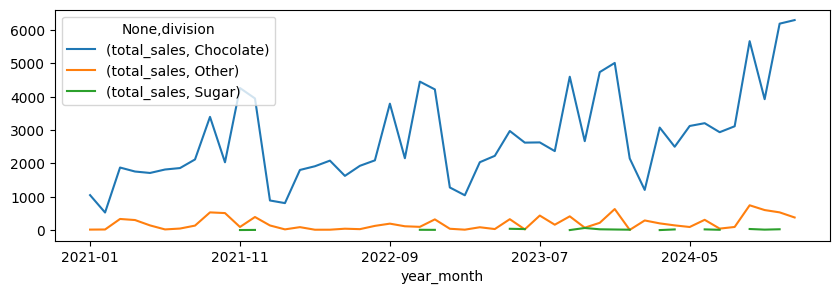

In [163]:
monthly_sales_by_division.unstack().plot(figsize=(10, 3))

In [164]:
yearly_sales_by_division = sales_df.groupby(["order_year", "division"]).agg(total_sales=("sales", "sum")).unstack(level=0).reset_index()
yearly_sales_by_division.columns = ["division", "2021", "2022", "2023", "2024"]
yearly_sales_by_division

,division,2021,2022,2023,2024
0,Chocolate,26356.36,27763.20,34193.38,43379.96
1,Other,2549.25,1207.75,2461.75,3444.50
2,Sugar,47.94,31.70,204.19,143.65


<Axes: >

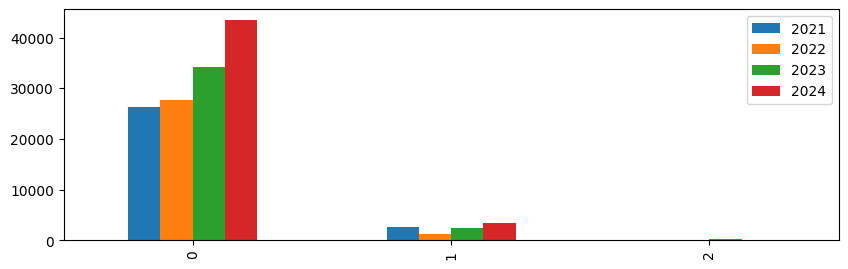

In [165]:
yearly_sales_by_division.plot(kind="bar", figsize=(10, 3))

## melt()

In [166]:
yearly_sales_by_division

,division,2021,2022,2023,2024
0,Chocolate,26356.36,27763.20,34193.38,43379.96
1,Other,2549.25,1207.75,2461.75,3444.50
2,Sugar,47.94,31.70,204.19,143.65


In [167]:
pd.melt(
    yearly_sales_by_division,
    id_vars=["division"],
    value_vars=["2021", "2022", "2023", "2024"],
    var_name="order_year",
    value_name="sales"
)

,division,order_year,sales
0,Chocolate,2021,26356.36
1,Other,2021,2549.25
2,Sugar,2021,47.94
3,Chocolate,2022,27763.20
4,Other,2022,1207.75
5,Sugar,2022,31.70
6,Chocolate,2023,34193.38
7,Other,2023,2461.75
8,Sugar,2023,204.19
9,Chocolate,2024,43379.96


### Question: Find the total monthly sales for each division. The division name should be in columns. For null sales values, replace it with the average monthly sales of a year for that division.

In [168]:
monthly_sales_by_division = sales_df.groupby(["order_year", "order_month", "division"]).agg({"sales": "sum"})
monthly_sales_by_division_unstacked = monthly_sales_by_division.unstack()

monthly_sales_by_division_unstacked.columns = ["chocolate", "other", "sugar"]

avg_monthly_sales = monthly_sales_by_division_unstacked.groupby(["order_year"]).transform("mean")

monthly_sales_by_division_unstacked.fillna(avg_monthly_sales)

chocolate   other     sugar
order_year order_month                             
2021       1              1049.24   16.00  11.98500
           2               527.84   19.25  11.98500
           3              1876.44  334.75  34.44000
           4              1756.72  302.25  11.98500
           5              1713.71  141.50  11.98500
           6              1817.18   21.25  11.98500
           7              1860.73   47.50  11.98500
           8              2118.46  135.50   4.50000
           9              3395.08  532.00  11.98500
           10             2033.63  511.25  11.98500
           11             4259.43   94.75   3.00000
           12             3947.90  393.25   6.00000
2022       1               888.66  140.00   7.92500
           2               810.03   22.75   7.92500
           3              1803.77   89.50   7.92500
           4              1915.01   12.25   1.99000
           5              2083.31   13.00   7.92500
           6              1626.33   42.75  11.25000
           7              1927.90   29.25   7.92500
           8              2091.69  127.50   7.92500
           9              3790.52  194.50   7.92500
           10             2155.35  115.75   7.92500
           11             4452.05   98.50   9.98000
           12             4218.58  322.00   8.48000
2023       1              1278.68   41.00  29.17000
           2              1044.56   13.75  29.17000
           3              2035.93   86.25  22.50000
           4              2226.94   32.50  29.17000
           5              2971.63  328.00  40.00000
           6              2623.08   23.25  31.50000
           7              2629.53  436.75  29.17000
           8              2369.23  162.50  29.17000
           9              4598.59  413.50   1.99000
           10             2666.58   73.00  64.50000
           11             4737.02  219.25  24.95000
           12             5011.61  632.00  18.75000
2024       1              2148.68    7.50  13.24000
           2              1205.34  290.00  17.95625
           3              3074.56  202.50   1.50000
           4              2499.50  142.50  21.00000
           5              3122.05   94.00  17.95625
           6              3205.60  309.00  22.50000
           7              2935.39   45.50  10.50000
           8              3113.37   95.00  17.95625
           9              5664.79  744.75  33.98000
           10             3925.06  601.75  15.00000
           11             6189.21  532.50  25.93000
           12             6296.41  379.50  17.95625

# Filtering null values

In [169]:
uszips_df.count()

zip                 33787
lat                 33787
lng                 33787
city                33787
state_id            33787
state_name          33787
zcta                33787
parent_zcta             0
population          33770
density             33770
county_fips         33787
county_name         33787
county_weights      33787
county_names_all    33787
county_fips_all     33787
imprecise           33787
military            33787
timezone            33787
dtype: int64

In [170]:
uszips_1 = uszips_df.dropna(how="all", axis=1)

In [171]:
uszips_1[uszips_1["population"].isna()].head()

,zip,lat,lng,city,state_id,state_name,zcta,population,density,county_fips,county_name,county_weights,county_names_all,county_fips_all,imprecise,military,timezone
91,00802,18.34349,-64.92870,St Thomas,VI,Virgin Islands,True,NaN,NaN,78030,St. Thomas,"{""78030"": 100}",St. Thomas,78030,False,False,America/St_Thomas
92,00820,17.73880,-64.70695,Christiansted,VI,Virgin Islands,True,NaN,NaN,78010,St. Croix,"{""78010"": 100}",St. Croix,78010,False,False,America/St_Thomas
93,00830,18.33857,-64.73802,St John,VI,Virgin Islands,True,NaN,NaN,78020,St. John,"{""78020"": 100}",St. John,78020,False,False,America/St_Thomas
94,00840,17.72649,-64.84717,Frederiksted,VI,Virgin Islands,True,NaN,NaN,78010,St. Croix,"{""78010"": 100}",St. Croix,78010,False,False,America/St_Thomas
95,00850,17.72763,-64.79122,Kingshill,VI,Virgin Islands,True,NaN,NaN,78010,St. Croix,"{""78010"": 100}",St. Croix,78010,False,False,America/St_Thomas


In [172]:
uszips_filter_nulls = uszips_1[~uszips_1["population"].isna()]
uszips_filter_nulls.count()

zip                 33770
lat                 33770
lng                 33770
city                33770
state_id            33770
state_name          33770
zcta                33770
population          33770
density             33770
county_fips         33770
county_name         33770
county_weights      33770
county_names_all    33770
county_fips_all     33770
imprecise           33770
military            33770
timezone            33770
dtype: int64

### Get the count of null values in a column

In [173]:
uszips_df.isna().sum()

zip                     0
lat                     0
lng                     0
city                    0
state_id                0
state_name              0
zcta                    0
parent_zcta         33787
population             17
density                17
county_fips             0
county_name             0
county_weights          0
county_names_all        0
county_fips_all         0
imprecise               0
military                0
timezone                0
dtype: int64

In [174]:
uszips_df.isna().sum().sum()

np.int64(33821)

## Date index

In [175]:
sales_df[(sales_df["order_date"] >= "2022-01-01") & (sales_df["order_date"] < "2022-02-01")]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
263,2064,US-2022-104241-CHO-TRI-54000,2022-01-04,2027-07-02,Standard Class,104241,United States,Alexandria,Virginia,22304,...,34.30,18.20,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
402,2060,US-2022-141243-CHO-MIL-31000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
403,2061,US-2022-141243-CHO-SCR-58000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,7.50,3.30,227.27,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
404,2063,US-2022-141243-CHO-NUT-13000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,12.45,5.00,249.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
405,2092,US-2022-151547-CHO-MIL-31000,2022-01-17,2027-07-16,Standard Class,151547,United States,Bartlett,Tennessee,38134,...,16.88,9.12,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,2054,US-2022-146262-CHO-FUD-51000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,4.80,2.40,200.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10046,2057,US-2022-146262-CHO-NUT-13000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,4.98,2.00,249.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10047,2058,US-2022-146262-CHO-MIL-31000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10048,2059,US-2022-146262-CHO-TRI-54000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,7.35,3.90,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01


In [176]:
sales_df[(sales_df["order_date"].dt.month == 1) & (sales_df["order_date"].dt.year == 2022)]

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
263,2064,US-2022-104241-CHO-TRI-54000,2022-01-04,2027-07-02,Standard Class,104241,United States,Alexandria,Virginia,22304,...,34.30,18.20,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
402,2060,US-2022-141243-CHO-MIL-31000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
403,2061,US-2022-141243-CHO-SCR-58000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,7.50,3.30,227.27,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
404,2063,US-2022-141243-CHO-NUT-13000,2022-01-03,2027-07-01,Second Class,141243,United States,Dallas,Texas,75217,...,12.45,5.00,249.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
405,2092,US-2022-151547-CHO-MIL-31000,2022-01-17,2027-07-16,Standard Class,151547,United States,Bartlett,Tennessee,38134,...,16.88,9.12,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10045,2054,US-2022-146262-CHO-FUD-51000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,4.80,2.40,200.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10046,2057,US-2022-146262-CHO-NUT-13000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,4.98,2.00,249.00,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10047,2058,US-2022-146262-CHO-MIL-31000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
10048,2059,US-2022-146262-CHO-TRI-54000,2022-01-02,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,...,7.35,3.90,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01


In [177]:
sales_date_idx = sales_df.sort_values(by="order_date").set_index("order_date")
sales_date_idx.head()

,row_id,order_id,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
order_date,,,,,,,,,,,,,,,,,,,,,
2021-01-03,1,US-2021-103800-CHO-MIL-31000,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,...,4.22,2.28,185.09,2021,1,1065.24,2954.32668,Wonka Bar,Wonka Bar,2021-01
2021-01-04,4,US-2021-112326-CHO-SCR-58000,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,...,7.50,3.30,227.27,2021,1,1065.24,2954.32668,Wonka Bar,Wonka Bar,2021-01
2021-01-04,3,US-2021-112326-CHO-NUT-13000,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,...,7.47,3.00,249.00,2021,1,1065.24,2954.32668,Wonka Bar,Wonka Bar,2021-01
2021-01-04,2,US-2021-112326-CHO-TRI-54000,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,...,4.90,2.60,188.46,2021,1,1065.24,2954.32668,Wonka Bar,Wonka Bar,2021-01
2021-01-05,5,US-2021-141817-CHO-TRI-54000,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,...,7.35,3.90,188.46,2021,1,1065.24,2954.32668,Wonka Bar,Wonka Bar,2021-01


In [178]:
sales_date_idx.loc["2022-01"]

,row_id,order_id,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
order_date,,,,,,,,,,,,,,,,,,,,,
2022-01-02,2058,US-2022-146262-CHO-MIL-31000,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,Chocolate,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2053,US-2022-104514-CHO-MIL-31000,2027-06-27,Second Class,104514,United States,Newark,Delaware,19711,Chocolate,...,6.33,3.42,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2055,US-2022-104514-CHO-SCR-58000,2027-06-27,Second Class,104514,United States,Newark,Delaware,19711,Chocolate,...,7.50,3.30,227.27,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2056,US-2022-104514-CHO-MIL-31000,2027-06-27,Second Class,104514,United States,Newark,Delaware,19711,Chocolate,...,4.22,2.28,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2059,US-2022-146262-CHO-TRI-54000,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,Chocolate,...,7.35,3.90,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-30,2111,US-2022-145401-CHO-SCR-58000,2027-07-28,Standard Class,145401,United States,Houston,Texas,77070,Chocolate,...,15.00,6.60,227.27,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-30,2110,US-2022-121797-CHO-MIL-31000,2027-07-30,Standard Class,121797,United States,Los Angeles,California,90049,Chocolate,...,14.77,7.98,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-31,2115,US-2022-149587-CHO-TRI-54000,2027-07-29,Second Class,149587,United States,Minneapolis,Minnesota,55407,Chocolate,...,4.90,2.60,188.46,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01


In [179]:
sales_2022_q1 = sales_date_idx.loc["2022-01":"2022-03"]
sales_2022_q1.head(3)

,row_id,order_id,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
order_date,,,,,,,,,,,,,,,,,,,,,
2022-01-02,2058,US-2022-146262-CHO-MIL-31000,2027-07-02,Standard Class,146262,United States,Medina,Ohio,44256,Chocolate,...,18.99,10.26,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2053,US-2022-104514-CHO-MIL-31000,2027-06-27,Second Class,104514,United States,Newark,Delaware,19711,Chocolate,...,6.33,3.42,185.09,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01
2022-01-02,2055,US-2022-104514-CHO-SCR-58000,2027-06-27,Second Class,104514,United States,Newark,Delaware,19711,Chocolate,...,7.50,3.30,227.27,2022,1,1028.66,2997.894775,Wonka Bar,Wonka Bar,2022-01


In [180]:
sales_2022_q1.reset_index()["order_date"].drop_duplicates()

0     2022-01-02
8     2022-01-03
12    2022-01-04
15    2022-01-05
21    2022-01-06
         ...    
249   2022-03-27
250   2022-03-28
255   2022-03-29
263   2022-03-30
266   2022-03-31
Name: order_date, Length: 62, dtype: datetime64[us]

In [181]:
sales_date_idx.loc["2023-04-01":"2023-04-03"]

,row_id,order_id,ship_date,ship_mode,customer_id,country_region,city,state_province,postal_code,division,...,gross_profit,cost,gross_profit_percent,order_year,order_month,total_monthly_sales,avg_monthly_sales_per_year,product_category,product_alternate_names,year_month
order_date,,,,,,,,,,,,,,,,,,,,,
2023-04-01,4528,US-2023-103947-CHO-SCR-58000,2028-09-28,Standard Class,103947,United States,Sierra Vista,Arizona,85635,Chocolate,...,5.00,2.20,227.27,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4537,US-2023-161473-CHO-TRI-54000,2028-09-25,Standard Class,161473,United States,New York City,New York,10035,Chocolate,...,4.90,2.60,188.46,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4530,US-2023-166674-CHO-SCR-58000,2028-09-23,Second Class,166674,United States,Auburn,New York,13021,Chocolate,...,15.00,6.60,227.27,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4526,US-2023-111213-CHO-FUD-51000,2028-09-25,Standard Class,111213,United States,New York City,New York,10009,Chocolate,...,14.40,7.20,200.00,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4540,US-2023-161473-CHO-MIL-31000,2028-09-25,Standard Class,161473,United States,New York City,New York,10035,Chocolate,...,6.33,3.42,185.09,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4538,US-2023-166674-CHO-TRI-54000,2028-09-23,Second Class,166674,United States,Auburn,New York,13021,Chocolate,...,7.35,3.90,188.46,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4533,US-2023-166674-CHO-TRI-54000,2028-09-23,Second Class,166674,United States,Auburn,New York,13021,Chocolate,...,7.35,3.90,188.46,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4534,US-2023-161473-CHO-NUT-13000,2028-09-25,Standard Class,161473,United States,New York City,New York,10035,Chocolate,...,7.47,3.00,249.00,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04
2023-04-01,4542,US-2023-166674-CHO-TRI-54000,2028-09-23,Second Class,166674,United States,Auburn,New York,13021,Chocolate,...,9.80,5.20,188.46,2023,4,2259.44,3667.322817,Wonka Bar,Wonka Bar,2023-04


In [182]:
sales_date_idx.loc["2022":"2024", ["product_name", "sales"]].groupby(["order_date", "product_name"])["sales"].sum()

order_date  product_name                     
2022-01-02  Wonka Bar - Fudge Mallows             7.20
            Wonka Bar - Milk Chocolate           45.50
            Wonka Bar - Nutty Crunch Surprise    24.43
            Wonka Bar - Triple Dazzle Caramel    11.25
            Wonka Bar -Scrumdiddlyumptious       10.80
                                                 ...  
2024-12-29  Wonka Bar -Scrumdiddlyumptious       68.40
2024-12-30  Wonka Bar - Milk Chocolate            9.75
            Wonka Bar - Nutty Crunch Surprise    13.96
            Wonka Bar - Triple Dazzle Caramel    48.75
            Wonka Bar -Scrumdiddlyumptious       21.60
Name: sales, Length: 3582, dtype: float64